# Laboratorio 12: Preparación de datos para un modelo de Machine Learning

## Conjunto de datos: Adult Census Income

**Nombre del alumno:** Roberto Herrera Zetina

**Entorno de trabajo:** Google Colab

---

## Propósito de la práctica

Desarrollar de forma ordenada el proceso de preparación, análisis y modelado de un conjunto de datos real destinado a una tarea de clasificación.

Durante el laboratorio se realizarán las siguientes actividades:

1. Importar las librerías requeridas.
2. Obtener y cargar el conjunto de datos.
3. Identificar el problema y las variables disponibles.
4. Realizar una exploración inicial de los datos.
5. Formular hipótesis y revisar correlaciones.
6. Definir las variables predictoras y la variable objetivo.
7. Detectar y tratar datos faltantes.
8. Convertir variables categóricas mediante One-Hot Encoding.
9. Separar los datos en entrenamiento y prueba.
10. Estandarizar las variables numéricas.
11. Entrenar un Árbol de Decisión.
12. Generar predicciones.
13. Medir el rendimiento del modelo.
14. Analizar la importancia de las características.
15. Elaborar respuestas y conclusiones.

---

## Planteamiento del problema

Se cuenta con información censal de diferentes personas. A partir de sus datos demográficos, educativos y laborales, se busca estimar si su ingreso anual se encuentra por debajo o por encima de los 50,000 dólares.

La clasificación considera dos posibles resultados:

- `<=50K`: ingreso anual de 50,000 dólares o menos.
- `>50K`: ingreso anual superior a 50,000 dólares.

El propósito del modelo no es calcular una cantidad exacta de dinero, sino asignar cada registro a una de estas dos categorías.

## 1. Importación de librerías

En esta sección se preparan las herramientas que se utilizarán para leer y transformar datos, crear visualizaciones, separar muestras, normalizar valores, entrenar el clasificador y revisar sus resultados.

El bloque también verifica que `kagglehub` esté disponible. Si Google Colab no lo tiene instalado, se agrega automáticamente.

In [1]:
# Instalación automática de KaggleHub cuando sea necesaria en Colab
import importlib.util
import subprocess
import sys

if importlib.util.find_spec("kagglehub") is None:
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-q", "kagglehub"
    ])

# Librerías para manejo de datos, visualización y Machine Learning
import os
from pathlib import Path

import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree

## 2. Carga del dataset

Primero se comprueba si `adult.csv` fue cargado manualmente en el directorio de Colab. Cuando el archivo no está disponible, el conjunto **Adult Census Income** se descarga desde KaggleHub.

Después se localiza el archivo CSV y se almacena en un DataFrame para comenzar el análisis.

In [2]:
# En Colab, el archivo cargado manualmente suele ubicarse en /content
posibles_archivos = [
    Path("/content/adult.csv"),
    Path("adult.csv")
]

archivo_csv = next(
    (archivo for archivo in posibles_archivos if archivo.exists()),
    None
)

# Si el CSV no fue cargado, se descarga el dataset desde KaggleHub
if archivo_csv is None:
    ruta_descarga = Path(
        kagglehub.dataset_download("uciml/adult-census-income")
    )
    coincidencias = list(ruta_descarga.rglob("adult.csv"))

    if not coincidencias:
        raise FileNotFoundError(
            "No fue posible localizar adult.csv dentro del dataset descargado."
        )

    archivo_csv = coincidencias[0]

print("Archivo utilizado:", archivo_csv)

dfAdult = pd.read_csv(archivo_csv)
dfAdult.head()

100%|██████████| 450k/450k [00:00<00:00, 32.4MB/s]

Extracting files...
Archivo utilizado: /root/.cache/kagglehub/datasets/uciml/adult-census-income/versions/3/adult.csv


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


## 3. Comprensión del problema y de las variables

La columna que se desea predecir es `income`. Sus valores dividen a las personas en dos grupos de ingreso anual:

- `<=50K`, para ingresos que no superan los 50,000 dólares.
- `>50K`, para ingresos mayores a esa cantidad.

El resto de las columnas describe aspectos como edad, escolaridad, ocupación, situación familiar, horas de trabajo y movimientos de capital. Estas características servirán como información de entrada para el modelo.

In [3]:
# Estructura, tipos de datos y distribución de la clase objetivo
dfAdult.info()

print("\nLista de columnas:")
print(dfAdult.columns.tolist())

print("\nFrecuencia de cada categoría de ingreso:")
dfAdult["income"].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB

Lista de columnas:
['age', 'workclass', 'fnlwgt', 'education', 'education.num', 'marital.sta

,count
income,
<=50K,24720
>50K,7841


## 4. Exploración inicial de datos (EDA)

Antes de aplicar transformaciones se revisa el tamaño del conjunto, la cantidad de columnas, la presencia de registros repetidos y el comportamiento general de las variables numéricas.

También se generan gráficas sencillas para observar el balance de la variable objetivo, la distribución de edades y la relación entre el promedio de horas trabajadas y la categoría de ingreso.

In [4]:
# Resumen general del conjunto de datos
print("Cantidad de registros:", dfAdult.shape[0])
print("Cantidad de columnas:", dfAdult.shape[1])
print("Filas duplicadas:", dfAdult.duplicated().sum())

dfAdult.describe()

Cantidad de registros: 32561
Cantidad de columnas: 15
Filas duplicadas: 24


,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


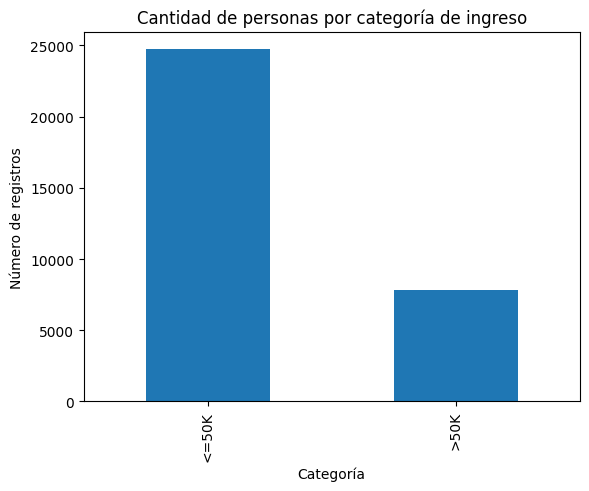

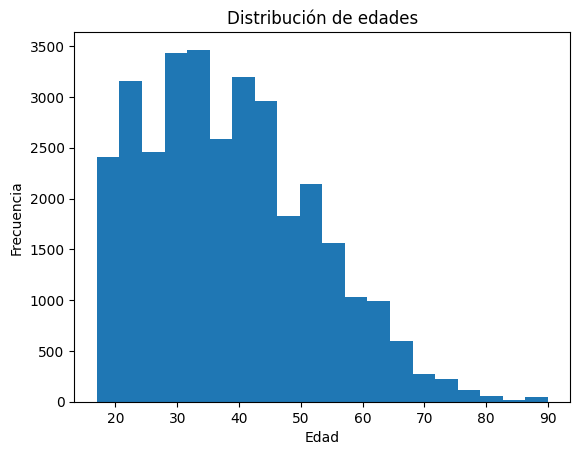

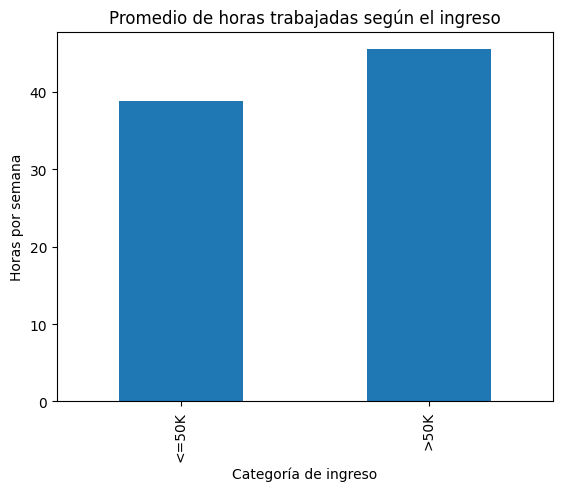

In [5]:
# Frecuencia de las clases de ingreso
dfAdult["income"].value_counts().plot(kind="bar")
plt.title("Cantidad de personas por categoría de ingreso")
plt.xlabel("Categoría")
plt.ylabel("Número de registros")
plt.show()

# Comportamiento de la variable edad
dfAdult["age"].plot(kind="hist", bins=20)
plt.title("Distribución de edades")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")
plt.show()

# Comparación del promedio de horas semanales por categoría
dfAdult.groupby("income")["hours.per.week"].mean().plot(kind="bar")
plt.title("Promedio de horas trabajadas según el ingreso")
plt.xlabel("Categoría de ingreso")
plt.ylabel("Horas por semana")
plt.show()

## 5. Tratamiento de valores nulos

Aunque varias columnas aparecen como completas al utilizar `info()`, el archivo utiliza el carácter `?` para representar información desconocida.

Por ese motivo, primero se sustituye dicho símbolo por `NaN`. Posteriormente, los valores faltantes de las columnas categóricas se reemplazan con la categoría más frecuente de cada columna. Esta estrategia permite conservar los registros sin introducir valores numéricos arbitrarios.

In [6]:
# El símbolo ? se interpreta como un dato faltante
dfAdult = dfAdult.replace("?", np.nan)

print("Valores faltantes antes del tratamiento:")
print(dfAdult.isnull().sum())

# Sustitución por la moda en las columnas categóricas incompletas
for columna in ["workclass", "occupation", "native.country"]:
    dfAdult[columna] = dfAdult[columna].fillna(
        dfAdult[columna].mode()[0]
    )

print("\nValores faltantes después del tratamiento:")
dfAdult.isnull().sum()

Valores faltantes antes del tratamiento:
age                  0
workclass         1836
fnlwgt               0
education            0
education.num        0
marital.status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital.gain         0
capital.loss         0
hours.per.week       0
native.country     583
income               0
dtype: int64

Valores faltantes después del tratamiento:


,0
age,0
workclass,0
fnlwgt,0
education,0
education.num,0
marital.status,0
occupation,0
relationship,0
race,0
sex,0


## 6. Correlación e hipótesis iniciales

Para incluir la variable objetivo en una matriz de correlación se crea una copia numérica temporal, donde `0` representa `<=50K` y `1` representa `>50K`.

**Hipótesis inicial:** las personas con mayor nivel educativo, más edad, más horas laborales o ganancias de capital podrían presentar una mayor probabilidad de pertenecer al grupo `>50K`. También es posible que la ocupación y el estado civil tengan una relación relevante con el resultado.

La correlación solo se calcula con variables numéricas; por lo tanto, las características categóricas se analizarán más adelante mediante el modelo.

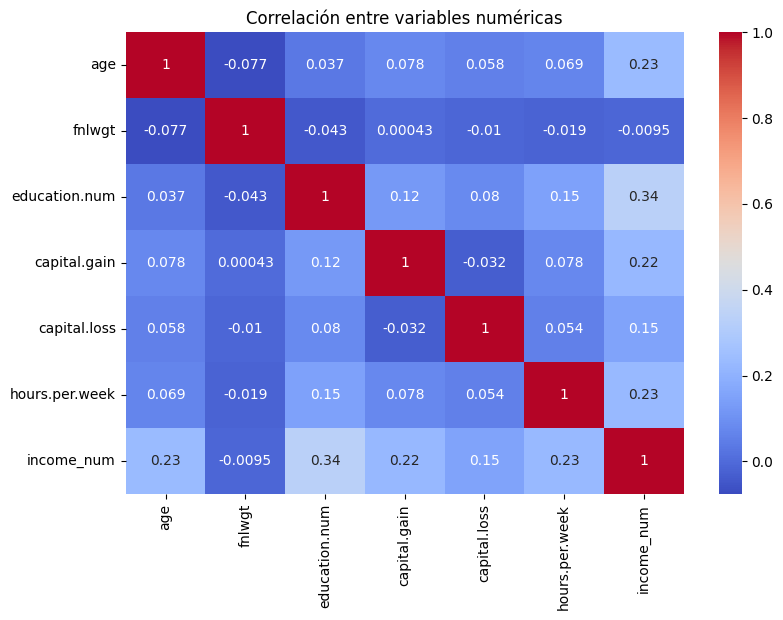

In [7]:
# Codificación temporal de la variable objetivo para la correlación
dfAdult["income_num"] = dfAdult["income"].map({
    "<=50K": 0,
    ">50K": 1
})

variables_numericas = [
    "age",
    "fnlwgt",
    "education.num",
    "capital.gain",
    "capital.loss",
    "hours.per.week",
    "income_num"
]

matriz_correlacion = dfAdult[variables_numericas].corr()

plt.figure(figsize=(9, 6))
sns.heatmap(
    matriz_correlacion,
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlación entre variables numéricas")
plt.show()

# La columna auxiliar ya no será necesaria
dfAdult = dfAdult.drop(columns=["income_num"])

## 7. Variables predictoras y variable objetivo

Se construyen dos elementos principales:

- `X`: contiene las 14 características que se usarán para realizar la predicción.
- `y`: contiene la clase de ingreso convertida a valores binarios.

La transformación de `income` a `0` y `1` facilita el entrenamiento y la evaluación del clasificador.

In [8]:
columnas_predictoras = [
    "age",
    "workclass",
    "fnlwgt",
    "education",
    "education.num",
    "marital.status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "capital.gain",
    "capital.loss",
    "hours.per.week",
    "native.country"
]

X = dfAdult[columnas_predictoras].copy()

y = dfAdult["income"].map({
    "<=50K": 0,
    ">50K": 1
})

print("Características seleccionadas:")
print(X.columns.tolist())

print("\nVariable que se predecirá:")
print(y.name)

Características seleccionadas:
['age', 'workclass', 'fnlwgt', 'education', 'education.num', 'marital.status', 'occupation', 'relationship', 'race', 'sex', 'capital.gain', 'capital.loss', 'hours.per.week', 'native.country']

Variable que se predecirá:
income


## 8. One-Hot Encoding

Las columnas categóricas contienen palabras y etiquetas que no pueden utilizarse directamente en el Árbol de Decisión. Para convertirlas a un formato numérico se aplica `pd.get_dummies()`.

Cada categoría genera una columna indicadora. Se utiliza `drop_first=True` para evitar conservar una columna redundante por cada variable original.

In [9]:
columnas_categoricas = [
    "workclass",
    "education",
    "marital.status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "native.country"
]

cantidad_inicial = X.shape[1]

X = pd.get_dummies(
    X,
    columns=columnas_categoricas,
    drop_first=True
)

cantidad_final = X.shape[1]

print("Columnas originales:", cantidad_inicial)
print("Columnas después de codificar:", cantidad_final)
print("Nuevas columnas generadas:", cantidad_final - cantidad_inicial)

X.head()

Columnas originales: 14
Columnas después de codificar: 97
Nuevas columnas generadas: 83


,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week,workclass_Local-gov,workclass_Never-worked,workclass_Private,workclass_Self-emp-inc,...,native.country_Portugal,native.country_Puerto-Rico,native.country_Scotland,native.country_South,native.country_Taiwan,native.country_Thailand,native.country_Trinadad&Tobago,native.country_United-States,native.country_Vietnam,native.country_Yugoslavia
0,90,77053,9,0,4356,40,False,False,True,False,...,False,False,False,False,False,False,False,True,False,False
1,82,132870,9,0,4356,18,False,False,True,False,...,False,False,False,False,False,False,False,True,False,False
2,66,186061,10,0,4356,40,False,False,True,False,...,False,False,False,False,False,False,False,True,False,False
3,54,140359,4,0,3900,40,False,False,True,False,...,False,False,False,False,False,False,False,True,False,False
4,41,264663,10,0,3900,40,False,False,True,False,...,False,False,False,False,False,False,False,True,False,False


## 9. División en entrenamiento y prueba

El conjunto transformado se separa en dos partes:

- 80% de los registros se utiliza para que el modelo aprenda patrones.
- 20% se reserva para comprobar su comportamiento con ejemplos no vistos durante el entrenamiento.

Se fija `random_state=42` para que la separación sea reproducible al volver a ejecutar el notebook.

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Se crean copias explícitas para trabajar de forma segura
X_train = X_train.copy()
X_test = X_test.copy()

print("Dimensiones de entrenamiento:", X_train.shape)
print("Dimensiones de prueba:", X_test.shape)

Dimensiones de entrenamiento: (26048, 97)
Dimensiones de prueba: (6513, 97)


## 10. Estandarización con StandardScaler

Las variables numéricas presentan rangos muy diferentes. Por ejemplo, `age` y `hours.per.week` manejan valores pequeños, mientras que `fnlwgt` puede contener cifras mucho mayores.

`StandardScaler` centra y ajusta estas variables a una escala comparable. El escalador se aprende únicamente con los datos de entrenamiento y después se aplica al conjunto de prueba, evitando utilizar información del conjunto reservado durante el ajuste.

In [11]:
columnas_numericas = [
    "age",
    "fnlwgt",
    "education.num",
    "capital.gain",
    "capital.loss",
    "hours.per.week"
]

escalador = StandardScaler()

X_train.loc[:, columnas_numericas] = escalador.fit_transform(
    X_train[columnas_numericas]
)

X_test.loc[:, columnas_numericas] = escalador.transform(
    X_test[columnas_numericas]
)

X_train[columnas_numericas].describe()

/tmp/ipykernel_4345/1430608107.py:12: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-0.92195464 -1.06915047 -0.18597545 ...  1.212385    0.18201414
 -1.21634631]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  X_train.loc[:, columnas_numericas] = escalador.fit_transform(
/tmp/ipykernel_4345/1430608107.py:12: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[ 0.63253053 -0.18615485 -1.08543674 ...  0.46047387 -0.34040696
 -0.25861078]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  X_train.loc[:, columnas_numericas] = escalador.fit_transform(
/tmp/ipykernel_4345/1430608107.py:12: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-0.42172678 -0.42172678  1.12825935 ... -0.42172678 -0.03423025
 -0.4

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
count,2.604800e+04,2.604800e+04,2.604800e+04,2.604800e+04,2.604800e+04,2.604800e+04
mean,-1.778539e-16,-1.020205e-16,1.669426e-16,-2.223174e-17,-5.673867e-17,5.251055e-18
std,1.000019e+00,1.000019e+00,1.000019e+00,1.000019e+00,1.000019e+00,1.000019e+00
min,-1.584336e+00,-1.690420e+00,-3.521699e+00,-1.471664e-01,-2.176795e-01,-3.204476e+00
25%,-7.747588e-01,-6.842442e-01,-4.217268e-01,-1.471664e-01,-2.176795e-01,-4.208134e-02
50%,-1.123775e-01,-1.078053e-01,-3.423025e-02,-1.471664e-01,-2.176795e-01,-4.208134e-02
75%,6.236017e-01,4.534354e-01,1.128259e+00,-1.471664e-01,-2.176795e-01,3.633539e-01
max,3.788312e+00,1.205002e+01,2.290749e+00,1.315328e+01,1.049046e+01,4.742055e+00


## 11. Entrenamiento del Árbol de Decisión

Se crea un clasificador de tipo Árbol de Decisión con una profundidad máxima de cuatro niveles. Esta restricción ayuda a mantener el modelo interpretable y reduce el riesgo de que memorice en exceso los datos de entrenamiento.

El parámetro `random_state=42` permite reproducir el mismo resultado en ejecuciones posteriores.

In [12]:
arbol = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)

arbol.fit(X_train, y_train)

print("El Árbol de Decisión fue entrenado correctamente.")

El Árbol de Decisión fue entrenado correctamente.


## 12. Predicciones

Una vez entrenado, el árbol procesa las características del conjunto de prueba y asigna a cada persona una clase estimada.

Para revisar ejemplos concretos se muestran, en una misma tabla, el valor real y la predicción producida por el modelo.

In [13]:
predicciones = arbol.predict(X_test)

comparacion = pd.DataFrame({
    "Clase real": y_test,
    "Clase predicha": predicciones
})

comparacion.head(30)

,Clase real,Clase predicha
14160,0,0
27048,0,0
28868,0,0
5667,0,0
7827,0,0
15382,0,0
4641,0,0
8943,0,0
216,0,0
5121,0,0


## 13. Evaluación: Accuracy, matriz de confusión y reporte de clasificación

El desempeño se analiza con tres recursos:

- **Accuracy:** proporción total de clasificaciones correctas.
- **Matriz de confusión:** cantidad de aciertos y errores para cada clase.
- **Reporte de clasificación:** precisión, sensibilidad (`recall`) y puntuación F1.

Estas métricas permiten observar no solo el resultado global, sino también si el modelo funciona de manera similar para ambos grupos de ingreso.

Accuracy: 0.8449
Porcentaje de aciertos: 84.49%

Matriz de confusión:
[[4728  248]
 [ 762  775]]


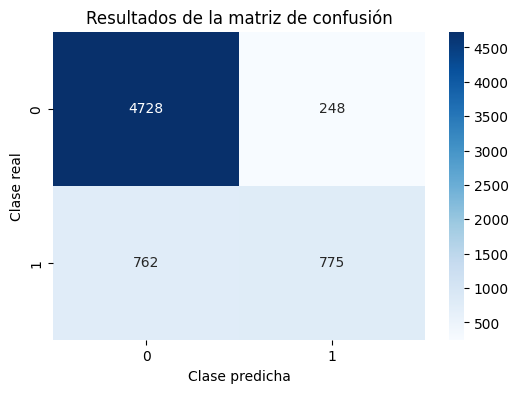

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.86      0.95      0.90      4976
           1       0.76      0.50      0.61      1537

    accuracy                           0.84      6513
   macro avg       0.81      0.73      0.75      6513
weighted avg       0.84      0.84      0.83      6513



In [14]:
exactitud = accuracy_score(y_test, predicciones)

print(f"Accuracy: {exactitud:.4f}")
print(f"Porcentaje de aciertos: {exactitud * 100:.2f}%")

matriz = confusion_matrix(y_test, predicciones)

print("\nMatriz de confusión:")
print(matriz)

plt.figure(figsize=(6, 4))
sns.heatmap(
    matriz,
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.title("Resultados de la matriz de confusión")
plt.xlabel("Clase predicha")
plt.ylabel("Clase real")
plt.show()

print("Reporte de clasificación:")
print(classification_report(y_test, predicciones))

### Lectura de la matriz de confusión

La matriz obtenida se interpreta de la siguiente manera:

- **4,728** registros de personas con ingreso `<=50K` se reconocieron correctamente.
- **775** registros del grupo `>50K` también se clasificaron de forma correcta.
- **248** personas de la clase `<=50K` fueron colocadas erróneamente en `>50K`.
- **762** personas que realmente pertenecían a `>50K` fueron predichas como `<=50K`.

Aunque el resultado global es favorable, el modelo distingue con mayor facilidad a la clase mayoritaria. El `recall` de la clase `>50K` es menor, por lo que una parte importante de las personas con ingresos altos no fue detectada.

## 14. Importancia de las variables (Feature Importance)

El Árbol de Decisión asigna un valor de importancia a las características que utiliza para dividir los datos.

En este apartado se ordenan dichos valores de mayor a menor para identificar qué variables influyeron más en las decisiones del modelo y cuáles no fueron utilizadas dentro de la profundidad establecida.

In [15]:
tabla_importancias = pd.DataFrame({
    "Variable": X_train.columns,
    "Importancia": arbol.feature_importances_
})

importancias_ordenadas = tabla_importancias.sort_values(
    by="Importancia",
    ascending=False
)

importancias_ordenadas.head(15)

,Variable,Importancia
29,marital.status_Married-civ-spouse,0.491686
2,education.num,0.248290
3,capital.gain,0.225830
4,capital.loss,0.021809
0,age,0.011251
1,fnlwgt,0.000966
37,occupation_Farming-fishing,0.000167
7,workclass_Never-worked,0.000000
5,hours.per.week,0.000000
9,workclass_Self-emp-inc,0.000000


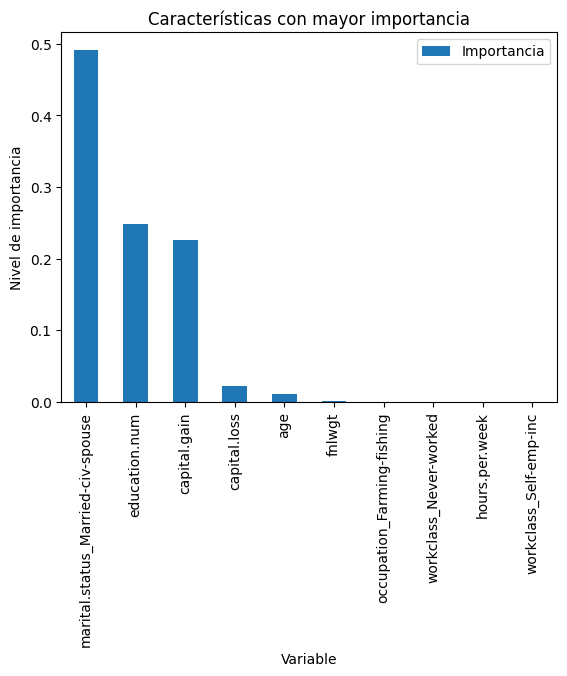

Característica con mayor importancia:
Variable       marital.status_Married-civ-spouse
Importancia                             0.491686
Name: 29, dtype: object

Número de características no utilizadas por el árbol:
90


In [16]:
# Representación de las diez características con mayor peso
importancias_ordenadas.head(10).plot(
    x="Variable",
    y="Importancia",
    kind="bar"
)
plt.title("Características con mayor importancia")
plt.ylabel("Nivel de importancia")
plt.xlabel("Variable")
plt.show()

print("Característica con mayor importancia:")
print(importancias_ordenadas.iloc[0])

print("\nNúmero de características no utilizadas por el árbol:")
print((importancias_ordenadas["Importancia"] == 0).sum())

### Visualización parcial del árbol

Un árbol completo con 97 columnas puede resultar difícil de leer. Para facilitar su interpretación se representan únicamente los primeros tres niveles, mostrando las reglas iniciales con las que el modelo separa las clases.

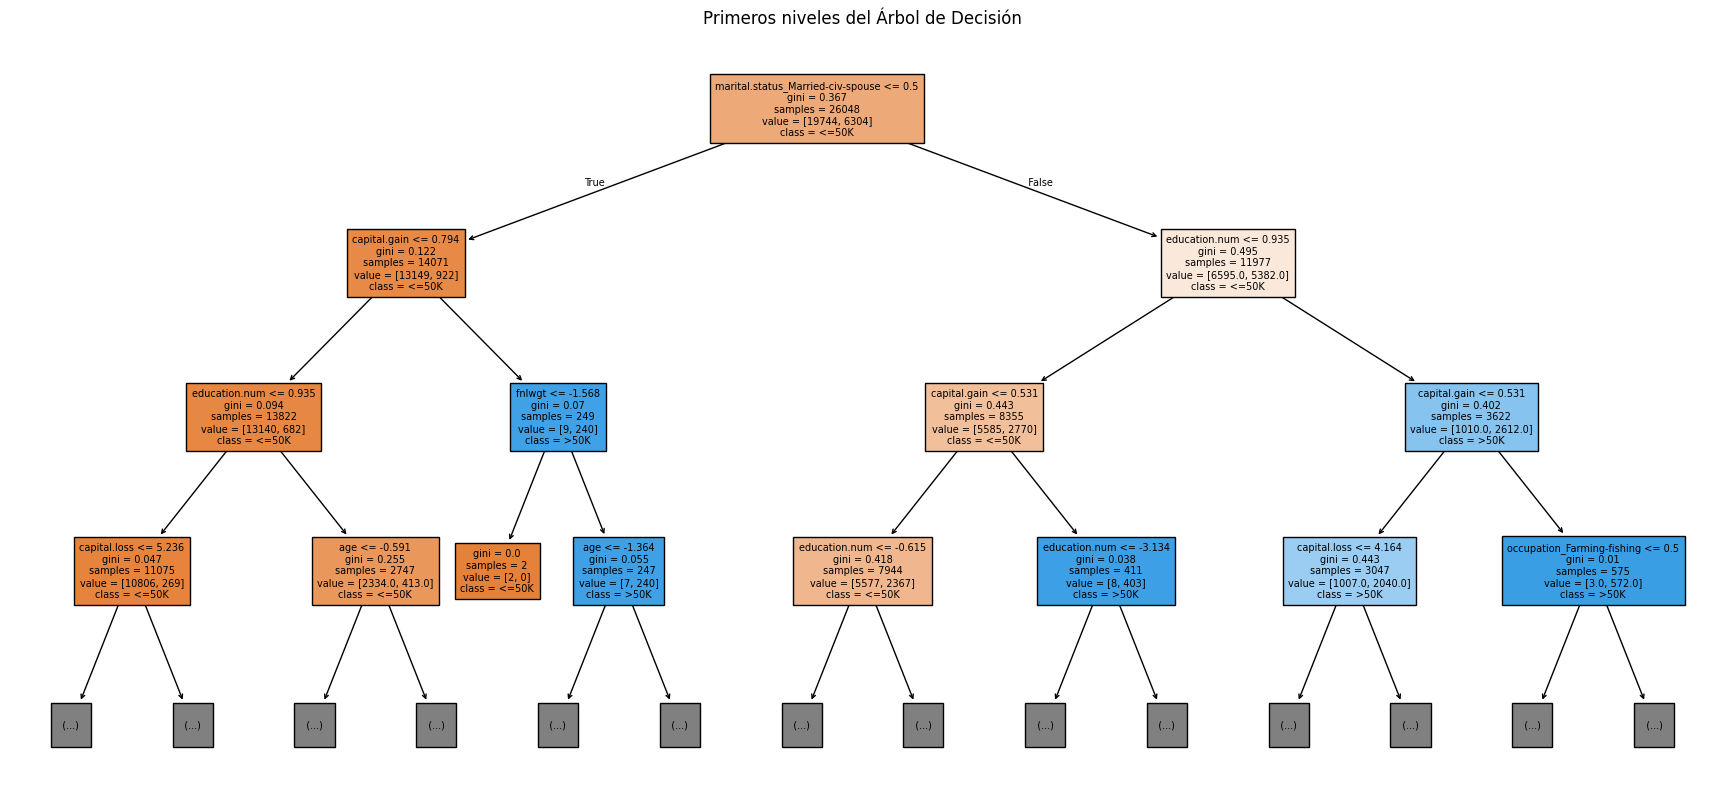

In [17]:
plt.figure(figsize=(22, 10))

plot_tree(
    arbol,
    max_depth=3,
    feature_names=X_train.columns,
    class_names=["<=50K", ">50K"],
    filled=True,
    fontsize=7
)

plt.title("Primeros niveles del Árbol de Decisión")
plt.show()

## Preguntas

1. **¿Cuál es la variable objetivo?**  
   La variable que se intenta predecir es `income`.

2. **¿Qué representa dicha variable?**  
   Indica la categoría del ingreso anual de cada persona: `<=50K` para 50,000 dólares o menos y `>50K` para una cantidad superior.

3. **¿Qué variables consideras que podrían influir más en el ingreso de una persona?**  
   Considero especialmente relevantes el nivel de estudios, la edad, el tipo de ocupación, las horas laboradas, el estado civil y las ganancias de capital, porque reflejan preparación, experiencia y situación laboral o económica.

4. **¿Cuántas variables predictoras existen?**  
   Antes de aplicar la codificación se seleccionaron **14 variables predictoras**.

5. **¿Por qué fue necesario transformar variables categóricas?**  
   Porque las categorías estaban escritas como texto y el algoritmo requiere datos numéricos. El One-Hot Encoding convierte cada categoría en indicadores que el modelo sí puede procesar.

7. **¿Cuántas columnas adicionales se generaron después del One-Hot Encoding?**  
   El conjunto pasó de **14 a 97 columnas**, de modo que se añadieron **83 características**.

8. **¿Existen valores nulos?**  
   Sí. Después de reemplazar `?` por `NaN` se detectaron **1,836** datos faltantes en `workclass`, **1,843** en `occupation` y **583** en `native.country`. Todos se completaron con la moda de su columna y al final no quedaron valores nulos.

9. **¿Qué variables son numéricas?**  
   Las variables numéricas utilizadas son `age`, `fnlwgt`, `education.num`, `capital.gain`, `capital.loss` y `hours.per.week`.

10. **¿Qué variables son categóricas?**  
    Las variables categóricas son `workclass`, `education`, `marital.status`, `occupation`, `relationship`, `race`, `sex` y `native.country`.

11. **¿Cuántos registros quedaron en entrenamiento?**  
    El conjunto de entrenamiento quedó formado por **26,048 registros**.

12. **¿Cuántos registros quedaron en prueba?**  
    Para la evaluación se reservaron **6,513 registros**.

13. **¿Por qué no debemos entrenar utilizando todos los datos?**  
    Porque sería imposible comprobar el comportamiento del modelo con información nueva. El conjunto de prueba funciona como una evaluación independiente y ayuda a detectar si el algoritmo solo memorizó los ejemplos de entrenamiento.

14. **¿Cuál fue el Accuracy obtenido?**  
    Se obtuvo un `accuracy` de **0.8449**, es decir, aproximadamente **84.49% de aciertos**.

15. **¿Consideras que el resultado es adecuado?**  
    Es un resultado aceptable como modelo inicial, ya que supera ampliamente una predicción al azar. Sin embargo, no debe evaluarse únicamente con el accuracy, porque el modelo tiene más dificultad para reconocer la clase `>50K`.

16. **¿Qué factores podrían afectar el desempeño del modelo?**  
    Pueden influir el desbalance entre las clases, la profundidad limitada del árbol, la forma de completar los datos faltantes, las características elegidas y la presencia de categorías con pocos ejemplos.

18. **¿Cuál fue la variable más importante?**  
    La característica con mayor peso fue `marital.status_Married-civ-spouse`, con una importancia cercana a 0.492.

19. **¿Cuál fue la menos importante?**  
    No se puede señalar una sola, porque **90 columnas tuvieron importancia igual a cero**. Esto significa que el árbol no necesitó utilizarlas en las divisiones realizadas con una profundidad máxima de cuatro.

20. **¿Coinciden los resultados con tus hipótesis iniciales?**  
    Coinciden parcialmente. El nivel educativo, la edad, las ganancias de capital y el estado civil sí aparecen entre los factores relevantes. En cambio, `hours.per.week` no fue utilizada por este árbol, aunque inicialmente se esperaba que tuviera mayor influencia.

21. **¿Qué variables aportan más información al modelo?**  
    Las características con mayor aporte fueron `marital.status_Married-civ-spouse`, `education.num`, `capital.gain`, `capital.loss`, `age`, `fnlwgt` y `occupation_Farming-fishing`. Las primeras tres concentran la mayor parte de la importancia total.

## 16. Conclusión

La práctica permitió recorrer un flujo completo de preparación de datos y clasificación. El conjunto Adult Income contiene 32,561 registros y combina información numérica con variables categóricas, por lo que fue necesario sustituir los valores `?`, completar datos faltantes y aplicar One-Hot Encoding antes del entrenamiento.

Después de la transformación se obtuvieron 97 características. Los datos se dividieron en una proporción de 80% para entrenamiento y 20% para prueba, mientras que las variables numéricas se estandarizaron utilizando únicamente la información del conjunto de entrenamiento.

El Árbol de Decisión alcanzó un accuracy de **84.49%**, lo cual representa una base útil para el problema. Sin embargo, la matriz de confusión muestra que el modelo reconoce mejor a las personas con ingresos `<=50K` que a quienes superan esa cantidad. Por ello, una mejora futura debería considerar el balance de clases, el ajuste de hiperparámetros y la comparación con algoritmos como Random Forest o regresión logística.

La variable con mayor influencia fue `marital.status_Married-civ-spouse`, seguida por `education.num` y `capital.gain`. Esto indica que la situación familiar, el nivel educativo y los movimientos de capital fueron los elementos más utilizados por el árbol para establecer sus reglas de clasificación.

En conclusión, el laboratorio demuestra que la calidad del preprocesamiento y la interpretación de varias métricas son tan importantes como el entrenamiento del modelo. Un accuracy alto por sí solo no garantiza que ambas clases sean identificadas con la misma eficacia.

# Entregable

```text
Notebooks/
└── Lab12
```

El archivo está preparado para ejecutarse en Google Colab. Para obtener todos los resultados y gráficas, se debe seleccionar **Entorno de ejecución → Ejecutar todas**. Si `adult.csv` no se carga manualmente, el notebook intentará descargarlo automáticamente mediante KaggleHub.